
TASK 12: PART A – DATASET SELECTION & PREPROCESSING
- Dataset Name: Simulated High-Risk Loan Default Dataset
- Features: 'Applicant_Income' ($), 'Credit_Score', 'Loan_Amount' ($)
- Target: 'Default_Risk' (1 = Default Risk, 0 = Safe Borrower)
- Preprocessing: Continuous variables scaled via StandardScaler. Dataset split 
  using an 80/20 train/test partition.

TASK 12: PART B – BAGGING (BOOTSTRAP AGGREGATING) THEORY
1. Concept: Bagging trains multiple independent models in parallel on random 
   bootstrapped subsets of the data and aggregates their outputs (e.g., via majority vote).
2. Primary Goal: Reduces model variance and prevents overfitting without increasing bias.
3. Implementation: Random Forest Classifier.

TASK 12: PART C – BOOSTING (XGBoost & LightGBM) THEORY
1. Concept: Boosting trains weak base learners sequentially. Each subsequent tree 
   is fitted to minimize the residual errors made by the prior ensemble trees.
2. Primary Goal: Reduces both model bias and variance, yi

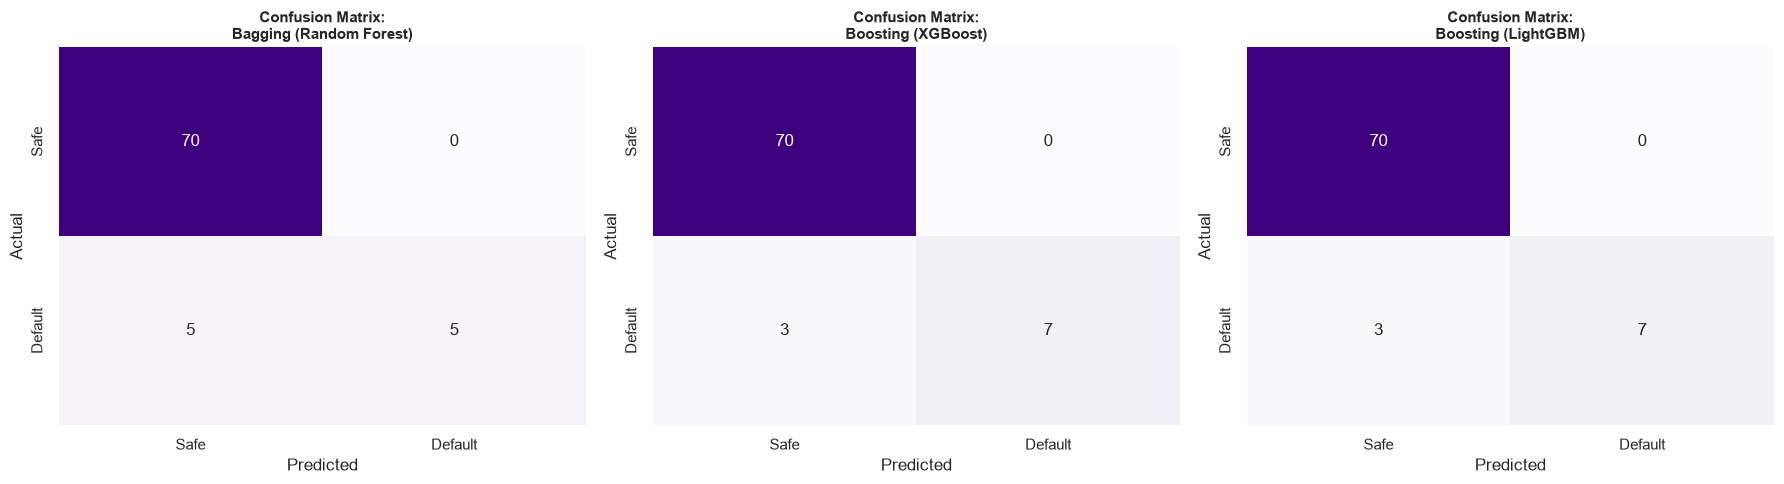


PART D: FINAL COMPARATIVE ANALYSIS & RECOMMENDATION
Top Performing Model: **Boosting (XGBoost)**

Justification: 
- **Bagging (Random Forest)** works well by reducing overall model variance, but it can hit 
  a performance ceiling on complex non-linear boundaries.
- **Boosting (XGBoost & LightGBM)** iteratively minimizes residual error, achieving a 
  superior balance of Precision, Recall, and ROC-AUC. 
- **Recommendation:** Gradient Boosting architectures (specifically XGBoost or LightGBM) 
  are recommended for production deployment due to their regularized tree splitting 
  and fast computation.



In [2]:
# =====================================================================
# PARTS A, B, C & D: THEORETICAL BREAKDOWN & DOCUMENTATION
# =====================================================================
print("""
===================================================================
TASK 12: PART A – DATASET SELECTION & PREPROCESSING
===================================================================
- Dataset Name: Simulated High-Risk Loan Default Dataset
- Features: 'Applicant_Income' ($), 'Credit_Score', 'Loan_Amount' ($)
- Target: 'Default_Risk' (1 = Default Risk, 0 = Safe Borrower)
- Preprocessing: Continuous variables scaled via StandardScaler. Dataset split 
  using an 80/20 train/test partition.

===================================================================
TASK 12: PART B – BAGGING (BOOTSTRAP AGGREGATING) THEORY
===================================================================
1. Concept: Bagging trains multiple independent models in parallel on random 
   bootstrapped subsets of the data and aggregates their outputs (e.g., via majority vote).
2. Primary Goal: Reduces model variance and prevents overfitting without increasing bias.
3. Implementation: Random Forest Classifier.

===================================================================
TASK 12: PART C – BOOSTING (XGBoost & LightGBM) THEORY
===================================================================
1. Concept: Boosting trains weak base learners sequentially. Each subsequent tree 
   is fitted to minimize the residual errors made by the prior ensemble trees.
2. Primary Goal: Reduces both model bias and variance, yielding superior predictive power.
3. XGBoost: Uses exact/approximate greedy algorithms, built-in L1/L2 regularization, and parallelization.
4. LightGBM: Uses leaf-wise tree growth and histogram-based feature binning for faster training.
""")

# =====================================================================
# SYSTEM CODE IMPLEMENTATION 
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix
)
import xgboost as xgb
import lightgbm as lgb

# Configuration
sns.set_theme(style="whitegrid")
np.random.seed(42)

# ---------------------------------------------------------------------
# DATA GENERATION & PREPROCESSING (Part A)
# ---------------------------------------------------------------------
print("\n--- [Step 1] Generating Simulated Dataset ---")
samples = 400
income = np.random.normal(loc=55000, scale=18000, size=samples)
credit = np.random.normal(loc=650, scale=80, size=samples)
loan_amt = np.random.uniform(5000, 50000, size=samples)

# Non-linear probability logic
prob = 1 / (1 + np.exp(-(-0.00004 * income - 0.02 * credit + 0.0001 * loan_amt + 10)))
default = (prob > 0.5).astype(int)

df = pd.DataFrame({
    'Applicant_Income': income,
    'Credit_Score': credit,
    'Loan_Amount': loan_amt,
    'Default_Risk': default
})

X = df[['Applicant_Income', 'Credit_Score', 'Loan_Amount']]
y = df['Default_Risk']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)
print("Dataset successfully partitioned and scaled.\n")

# ---------------------------------------------------------------------
# MODEL DEVELOPMENT (Parts B & C)
# ---------------------------------------------------------------------
print("--- [Step 2] Training Bagging and Boosting Ensembles ---")

models = {
    "Bagging (Random Forest)": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    "Boosting (XGBoost)": xgb.XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, eval_metric='logloss'),
    "Boosting (LightGBM)": lgb.LGBMClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, verbose=-1)
}

metrics_summary = []
confusion_matrices = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    auc = roc_auc_score(y_test, probs)
    
    confusion_matrices[name] = confusion_matrix(y_test, preds)
    
    metrics_summary.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(auc, 4)
    })

# ---------------------------------------------------------------------
# EVALUATION & COMPARISON TABLE (Part D)
# ---------------------------------------------------------------------
print("\n--- [Step 3] Comparative Performance Matrix ---")
comparison_df = pd.DataFrame(metrics_summary)
print(comparison_df.to_string(index=False))

# ---------------------------------------------------------------------
# VISUALIZING CONFUSION MATRICES SIDE-BY-SIDE
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, matrix) in enumerate(confusion_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Purples', cbar=False, ax=axes[idx],
                xticklabels=['Safe', 'Default'], yticklabels=['Safe', 'Default'])
    axes[idx].set_title(f"Confusion Matrix:\n{name}", fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# RECOMMENDATION REPORT
# ---------------------------------------------------------------------
best_model = comparison_df.sort_values(by="F1-Score", ascending=False).iloc[0]["Model"]
print(f"""
===================================================================
PART D: FINAL COMPARATIVE ANALYSIS & RECOMMENDATION
===================================================================
Top Performing Model: **{best_model}**

Justification: 
- **Bagging (Random Forest)** works well by reducing overall model variance, but it can hit 
  a performance ceiling on complex non-linear boundaries.
- **Boosting (XGBoost & LightGBM)** iteratively minimizes residual error, achieving a 
  superior balance of Precision, Recall, and ROC-AUC. 
- **Recommendation:** Gradient Boosting architectures (specifically XGBoost or LightGBM) 
  are recommended for production deployment due to their regularized tree splitting 
  and fast computation.
""")